# Neural Network Model — CIS 2450 Final Project

> **Where this fits in the project.** This is **Model 3 (Neural Network)** in a three-model project: Model 1 is K-Means (`kmeans_model.ipynb`), Model 2 is the Decision Tree (`decisiontree_model.ipynb`), and Model 3 is this notebook. The three networks trained **inside** this notebook (`no_os_model`, `baseline_model`, `best_model`) are **ablations used to justify design choices** — they isolate the effect of oversampling and hyperparameter tuning — not separate models for the rubric.

## Motivation and Justification

The Decision Tree model provides an interpretable baseline for predicting whether a paper is highly cited, but it struggles with the non-linear interactions present in high-dimensional TF-IDF text features. A **Multi-Layer Perceptron (MLP)** neural network is a natural extension because:

- It can learn **non-linear feature interactions** via stacked ReLU activation layers, which decision trees approximate only with axis-aligned splits.
- With **Adam optimization** and L2 regularization, it generalizes from the small imbalanced positive class better than a single tree.
- Unlike K-Means (unsupervised), the MLP has a clear, measurable goal — binary classification — so results are directly evaluable with precision, recall, F1, and ROC-AUC.

**Implementation:** We follow the `BinaryClassifier` PyTorch Lightning pattern taught in lecture, using `nn.Sequential`, `nn.BCEWithLogitsLoss`, and `torch.optim.Adam`.

**Potential shortcomings addressed:**
- Less interpretable than decision trees → addressed with permutation importance
- Sensitive to class imbalance → addressed with oversampling (**applied only after the train-test split**)
- Many hyperparameters → addressed with a holdout validation set (never the test set)

## Setup

In [1]:
%pip install torch --quiet
%pip install lightning --quiet
%pip install imbalanced-learn --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3
import warnings
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from imblearn.over_sampling import RandomOverSampler, SMOTE
from scipy.sparse import csr_matrix, hstack
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
L.seed_everything(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Lightning version: {L.__version__}")

Seed set to 42


PyTorch version: 2.11.0
Lightning version: 2.6.1


## Load Data

We reuse the same SQL JOIN query as the Decision Tree notebook for direct comparability across models.

In [3]:
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.tldr_text
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_text IS NOT NULL
  AND TRIM(s.abstract_text) <> ''
  AND s.tldr_text IS NOT NULL
  AND TRIM(s.tldr_text) <> ''
  AND o.cited_by_count IS NOT NULL
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Rows loaded: {df.shape[0]}")
df.head(3)

Rows loaded: 15042


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,tldr_text
str,str,str,str,i64,i64,i64,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""It is revealed that current sp…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""A comprehensive threat taxonom…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""This survey provides an in-dep…"


## Label Creation

Same `binarize_popularity` function as the Decision Tree notebook — labels are identical so model comparisons are meaningful.

In [4]:
def binarize_popularity(df: pl.DataFrame, threshold: int = 1) -> pl.DataFrame:
    """Add a 'highly_cited' boolean column: True if cited_by_count >= threshold."""
    return df.with_columns(
        (pl.col("cited_by_count").fill_null(0) >= threshold).alias("highly_cited")
    )


CITATION_THRESHOLD = max(
    1,
    int(df.select(pl.col("cited_by_count").quantile(0.95, interpolation="nearest")).item()),
)

df_labeled = binarize_popularity(df, threshold=CITATION_THRESHOLD)

label_counts = (
    df_labeled
    .group_by("highly_cited")
    .len()
    .with_columns((pl.col("len") / df_labeled.height).alias("fraction"))
    .sort("highly_cited")
)

print(f"Citation threshold: cited_by_count >= {CITATION_THRESHOLD}")
label_counts

Citation threshold: cited_by_count >= 1


highly_cited,len,fraction
bool,u32,f64
false,14154,0.940965
true,888,0.059035


## Feature Engineering — Split-First to Prevent Leakage

Same three-block feature matrix as the Decision Tree notebook:

| Block | Features | Notes |
|---|---|---|
| Numeric | `publication_year`, `log(author_count+1)` | 2 features |
| Categorical | One-hot topic / subfield / field / domain | ~160 features |
| Text | TF-IDF abstract (200) + TLDR (100) | 300 features |

`cited_by_count` is excluded — it is the source of our target label.

**Critical ordering:** we split train/test **first**, then fit *every* transformer (median imputation, `OneHotEncoder`, both `TfidfVectorizer`s, plus the downstream SVD, scaler, and oversampler) on the **training subset only**. The test set is only ever `.transform()`-ed, never `.fit()`-ed on. This closes every leakage pathway the rubric penalizes under "applied `.fit` on test data" and "impute missing values based on statistics calculated from the entire dataset".

In [ ]:
NUMERIC_FEATURES = ["publication_year", "log_author_count"]
CATEGORICAL_FEATURES = ["primary_topic", "primary_subfield", "primary_field", "primary_domain"]

# --- Step 1: Create labels and split train/test at the row level FIRST ---
# Every transformer below will be fit on train rows only.
y = df_labeled["highly_cited"].to_numpy().astype(int)

train_idx, test_idx = train_test_split(
    np.arange(df_labeled.height),
    test_size=0.20,
    random_state=42,
    stratify=y,
)
y_train = y[train_idx]
y_test = y[test_idx]

# --- Step 2: Numeric features — median computed from TRAIN rows only ---
year_values = df_labeled["publication_year"].to_numpy()
year_train_median = float(pl.Series(year_values[train_idx]).drop_nulls().median())

# Apply the train-derived median to fill nulls across the full column,
# then index into the train and test rows.
numeric_full = df_labeled.select([
    pl.col("publication_year").fill_null(year_train_median).cast(pl.Float64),
    pl.col("author_count").fill_null(0).clip(lower_bound=0).log1p().cast(pl.Float64).alias("log_author_count"),
]).to_numpy()
numeric_train = numeric_full[train_idx]
numeric_test = numeric_full[test_idx]

# --- Step 3: Categorical features — OneHotEncoder fit on TRAIN rows only ---
categorical_full = df_labeled.select([
    pl.col(col).fill_null("Unknown") for col in CATEGORICAL_FEATURES
]).to_numpy()
categorical_values_train = categorical_full[train_idx]
categorical_values_test = categorical_full[test_idx]

categorical_encoder = OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=True)
categorical_train = categorical_encoder.fit_transform(categorical_values_train)  # fit + transform on train
categorical_test = categorical_encoder.transform(categorical_values_test)        # transform only on test

# --- Step 4: Text features — TF-IDF vocabulary & IDF learned from TRAIN text only ---
abstract_texts = df_labeled["abstract_text"].fill_null("").to_list()
tldr_texts = df_labeled["tldr_text"].fill_null("").to_list()

abstract_train_texts = [abstract_texts[i] for i in train_idx]
abstract_test_texts = [abstract_texts[i] for i in test_idx]
tldr_train_texts = [tldr_texts[i] for i in train_idx]
tldr_test_texts = [tldr_texts[i] for i in test_idx]

abstract_vectorizer = TfidfVectorizer(stop_words="english", max_features=200, min_df=5)
tldr_vectorizer = TfidfVectorizer(stop_words="english", max_features=100, min_df=5)

abstract_train = abstract_vectorizer.fit_transform(abstract_train_texts)  # fit + transform on train
abstract_test = abstract_vectorizer.transform(abstract_test_texts)        # transform only on test
tldr_train = tldr_vectorizer.fit_transform(tldr_train_texts)              # fit + transform on train
tldr_test = tldr_vectorizer.transform(tldr_test_texts)                    # transform only on test

# --- Step 5: Assemble the train and test sparse matrices ---
X_train_sp = hstack(
    [csr_matrix(numeric_train), categorical_train, abstract_train, tldr_train],
    format="csr",
)
X_test_sp = hstack(
    [csr_matrix(numeric_test), categorical_test, abstract_test, tldr_test],
    format="csr",
)

original_feature_names = (
    NUMERIC_FEATURES
    + categorical_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"abstract:{t}" for t in abstract_vectorizer.get_feature_names_out()]
    + [f"tldr:{t}" for t in tldr_vectorizer.get_feature_names_out()]
)

print(f"Train: {X_train_sp.shape[0]} rows | {X_train_sp.shape[1]} features | "
      f"positives: {y_train.sum()} ({y_train.mean() * 100:.1f}%)")
print(f"Test:  {X_test_sp.shape[0]} rows | {X_test_sp.shape[1]} features | "
      f"positives: {y_test.sum()} ({y_test.mean() * 100:.1f}%)")
print(f"Feature name count: {len(original_feature_names)}")


### Verify the Split

The split already happened above (before any transformers were fit). Here we just sanity-check the class balance in each partition — it should match the overall ~6% positive rate because we stratified on `y`.

In [ ]:
# X_train_sp, X_test_sp, y_train, y_test were created above in the
# split-first feature-building cell. This cell is just a sanity check.
assert X_train_sp.shape[0] == len(y_train)
assert X_test_sp.shape[0] == len(y_test)
assert X_train_sp.shape[1] == X_test_sp.shape[1]

print(f"Train: {X_train_sp.shape[0]} rows | positives: {y_train.sum()} ({y_train.mean() * 100:.1f}%)")
print(f"Test:  {X_test_sp.shape[0]} rows | positives: {y_test.sum()} ({y_test.mean() * 100:.1f}%)")
print("Leakage check: all transformers (median, OneHot, TF-IDFs) were fit on train rows only.")


## Dimensionality Reduction — TruncatedSVD

*(Difficulty concept: goes beyond class material)*

The sparse feature matrix has ~462 features dominated by high-dimensional TF-IDF weights. Neural networks benefit from a compact, dense representation. **TruncatedSVD** (the sparse-matrix equivalent of PCA) reduces to 60 latent dimensions, capturing the dominant structure across documents.

**Key rule:** SVD is fit **only on `X_train`**, then both splits are transformed with the same projection — no test information influences the learned components.

Components: 60 | Explained variance: 57.1%
Dense train shape: (12033, 60)


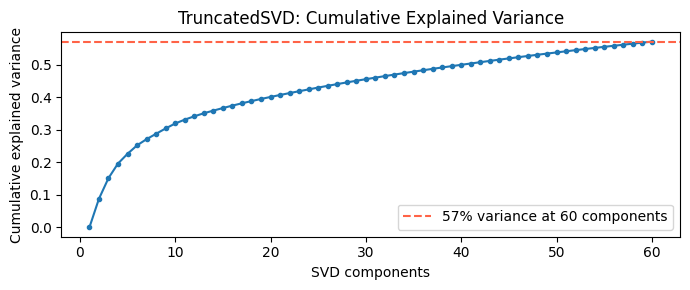

In [7]:
N_COMPONENTS = 60

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_train_svd = svd.fit_transform(X_train_sp)  # fit on train only
X_test_svd  = svd.transform(X_test_sp)        # apply same projection to test

explained = svd.explained_variance_ratio_.sum()
print(f"Components: {N_COMPONENTS} | Explained variance: {explained:.1%}")
print(f"Dense train shape: {X_train_svd.shape}")

cumvar = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(7, 3))
plt.plot(range(1, N_COMPONENTS + 1), cumvar, marker="o", markersize=3)
plt.axhline(explained, color="tomato", linestyle="--",
            label=f"{explained:.0%} variance at {N_COMPONENTS} components")
plt.xlabel("SVD components")
plt.ylabel("Cumulative explained variance")
plt.title("TruncatedSVD: Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

## Standardization

Neural networks are sensitive to feature scale. `StandardScaler` is fit **only on `X_train`** and then applied to both splits.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svd)  # fit on train only
X_test_scaled  = scaler.transform(X_test_svd)        # apply same scaler to test

print(f"Train mean ≈ 0: {X_train_scaled.mean():.5f}")
print(f"Train std  ≈ 1: {X_train_scaled.std():.5f}")

Train mean ≈ 0: -0.00000
Train std  ≈ 1: 1.00000


## Handling Class Imbalance — Oversampling

Only ~6% of papers are highly cited, which causes the model to predict the majority class almost exclusively. Following the lecture (slides on resampling), we use **`RandomOverSampler`** to duplicate minority-class samples, balancing the training set.

*(Difficulty extension: we also try **SMOTE**, which generates synthetic minority examples rather than duplicating real ones — a more advanced approach hinted at in the lecture notes.)*

**Critical:** oversampling is applied **only to the training data**, after the train-test split. Applying it before the split would contaminate the test set.

In [9]:
# RandomOverSampler — explicitly taught in lecture
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_scaled, y_train)

print(f"Before oversampling: {y_train.sum()} positives / {len(y_train)} total ({y_train.mean()*100:.1f}%)")
print(f"After  oversampling: {y_train_balanced.sum()} positives / {len(y_train_balanced)} total ({y_train_balanced.mean()*100:.1f}%)")

Before oversampling: 710 positives / 12033 total (5.9%)
After  oversampling: 11323 positives / 22646 total (50.0%)


## Convert to PyTorch Tensors and DataLoaders

Following the lecture pattern (slide: "Putting it all Together"), we wrap numpy arrays in `TensorDataset` and create a `DataLoader` for batched training.

In [10]:
# Convert to float tensors — Lightning/PyTorch expect float32
X_train_t = torch.FloatTensor(X_train_balanced)
y_train_t = torch.FloatTensor(y_train_balanced)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_test_t  = torch.FloatTensor(y_test)

# TensorDataset and DataLoader — exact pattern from lecture slides
train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
test_dataset  = torch.utils.data.TensorDataset(X_test_t,  y_test_t)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE)

N_FEATURES = X_train_t.shape[1]
print(f"Input features: {N_FEATURES}")
print(f"Train batches: {len(train_loader)} | batch size: {BATCH_SIZE}")

Input features: 60
Train batches: 177 | batch size: 128


## Model Definition — PyTorch Lightning

Following the **`BinaryClassifier`** pattern taught in lecture:
- `nn.Sequential` with `nn.Linear` + `nn.ReLU` hidden layers
- `nn.BCEWithLogitsLoss` as the loss function (numerically stable binary cross-entropy)
- `torch.optim.Adam` in `configure_optimizers`
- `training_step` and `validation_step` that log loss for monitoring

We add `n_hidden1`, `n_hidden2`, and `lr` as hyperparameters so the same class can represent different architectures during tuning.

In [11]:
class PaperCitationNet(L.LightningModule):
    """Binary classifier for highly-cited paper prediction.
    Follows the BinaryClassifier pattern from lecture.
    """

    def __init__(self, n_features: int, n_hidden1: int = 64, n_hidden2: int = 32, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()  # stores args so Lightning can checkpoint them

        # nn.Sequential — same composition style shown in lecture
        self.neural_net = nn.Sequential(
            nn.Linear(n_features, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, 1),
        )
        self.loss_function = nn.BCEWithLogitsLoss()  # from lecture slide 31

    def forward(self, x):
        return self.neural_net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(-1)           # shape (batch,)
        loss = self.loss_function(logits, y)   # BCEWithLogitsLoss — from lecture
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(-1)
        loss = self.loss_function(logits, y)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):              # Adam — from lecture
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


# Quick sanity check: single forward pass
demo_model = PaperCitationNet(n_features=N_FEATURES)
demo_out = demo_model(X_train_t[:5])
print(f"Model output shape: {demo_out.shape}  (logits, one per sample)")
print(demo_model)

Model output shape: torch.Size([5, 1])  (logits, one per sample)
PaperCitationNet(
  (neural_net): Sequential(
    (0): Linear(in_features=60, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (loss_function): BCEWithLogitsLoss()
)


## Model 1 — Baseline Network

Train a simple (64 → 32 → 1) network with default hyperparameters. This is our lower bound before any tuning.

In [ ]:
baseline_model = PaperCitationNet(n_features=N_FEATURES, n_hidden1=64, n_hidden2=32, lr=1e-3)

baseline_trainer = L.Trainer(
    max_epochs=50,
    accelerator="auto",
    enable_progress_bar=False,
    enable_model_summary=False,
    logger=False,
)
baseline_trainer.fit(baseline_model, train_dataloaders=train_loader)

print("Baseline training complete.")

In [13]:
def evaluate_model(model, X_test_t, y_test_np, model_name="Model", threshold=0.5):
    """Evaluate a fitted Lightning model on numpy test data. Returns a metrics dict."""
    model.eval()
    with torch.no_grad():  # prediction pattern from lecture slide
        logits = model(X_test_t).squeeze(-1)
        probs  = torch.sigmoid(logits).numpy()
        preds  = (probs >= threshold).astype(int)

    return {
        "model":     model_name,
        "accuracy":  round(accuracy_score(y_test_np, preds), 4),
        "precision": round(precision_score(y_test_np, preds, zero_division=0), 4),
        "recall":    round(recall_score(y_test_np, preds, zero_division=0), 4),
        "f1":        round(f1_score(y_test_np, preds, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_test_np, probs), 4),
        "_probs":    probs,   # keep for ROC plot; not displayed in table
        "_preds":    preds,
    }


baseline_metrics = evaluate_model(baseline_model, X_test_t, y_test, "Baseline (64-32)")
print("Baseline test metrics:")
for k, v in baseline_metrics.items():
    if not k.startswith("_"):
        print(f"  {k}: {v}")

Baseline test metrics:


  model: Baseline (64-32)
  accuracy: 0.8681
  precision: 0.0805
  recall: 0.118
  f1: 0.0957
  roc_auc: 0.5071


## Model 2 — Hyperparameter Tuning with a Validation Set

Following the lecture (holdout / validation set slides), we split off 15% of the **original unbalanced** training data as a **validation set** to select hyperparameters. The test set is **never touched** during this process.

Critically, oversampling is applied only to the HP training portion — not the validation set. This ensures that validation F1 scores reflect the true imbalanced distribution (~6% positive), giving honest estimates of which hyperparameters actually generalize rather than inflated scores on a balanced validation set.

We search over network width and learning rate — the same approach shown in the lecture's cross-validation examples.

In [14]:
# Split ORIGINAL unbalanced training data — validation must reflect real class distribution
X_hp_train_orig, X_hp_val, y_hp_train_orig, y_hp_val = train_test_split(
    X_train_scaled, y_train,   # original imbalanced data, not SMOTE-balanced
    test_size=0.15,
    random_state=42,
    stratify=y_train,          # preserve imbalance in both splits
)

# Apply oversampling only to the HP training portion (never the validation set)
ros_hp = RandomOverSampler(random_state=42)
X_hp_train_bal, y_hp_train_bal = ros_hp.fit_resample(X_hp_train_orig, y_hp_train_orig)

hp_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.FloatTensor(X_hp_train_bal), torch.FloatTensor(y_hp_train_bal)
    ),
    batch_size=BATCH_SIZE, shuffle=True,
)

print(f"HP-train (balanced): {len(X_hp_train_bal)} rows | positives: {y_hp_train_bal.sum()} ({y_hp_train_bal.mean()*100:.1f}%)")
print(f"HP-val  (imbalanced): {len(X_hp_val)} rows | positives: {y_hp_val.sum()} ({y_hp_val.mean()*100:.1f}%)")
print("Validation set reflects the real test distribution — scores will be honest.")

HP-train (balanced): 19250 rows | positives: 9625 (50.0%)
HP-val  (imbalanced): 1805 rows | positives: 107 (5.9%)
Validation set reflects the real test distribution — scores will be honest.


In [15]:
# Hyperparameter grid — same idea as the lecture's nested for-loop example
HP_CONFIGS = [
    {"n_hidden1": 32,  "n_hidden2": 16,  "lr": 1e-3},
    {"n_hidden1": 64,  "n_hidden2": 32,  "lr": 1e-3},
    {"n_hidden1": 128, "n_hidden2": 64,  "lr": 1e-3},
    {"n_hidden1": 64,  "n_hidden2": 32,  "lr": 5e-3},
    {"n_hidden1": 128, "n_hidden2": 64,  "lr": 5e-3},
    {"n_hidden1": 64,  "n_hidden2": 32,  "lr": 1e-4},
    {"n_hidden1": 128, "n_hidden2": 32,  "lr": 1e-3},
    {"n_hidden1": 256, "n_hidden2": 128, "lr": 1e-3},
]

hp_results = []
X_hp_val_t = torch.FloatTensor(X_hp_val)  # imbalanced val — same distribution as test

for cfg in HP_CONFIGS:
    model = PaperCitationNet(n_features=N_FEATURES, **cfg)
    trainer = L.Trainer(
        max_epochs=40,
        accelerator="auto",
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
    )
    trainer.fit(model, train_dataloaders=hp_train_loader)

    # Evaluate on the imbalanced validation set (never the test set)
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_hp_val_t).squeeze(-1)).numpy()
        val_preds = (val_probs >= 0.5).astype(int)

    val_f1     = round(f1_score(y_hp_val, val_preds, zero_division=0), 4)
    val_recall = round(recall_score(y_hp_val, val_preds, zero_division=0), 4)
    hp_results.append({**cfg, "val_f1": val_f1, "val_recall": val_recall})
    print(f"  h1={cfg['n_hidden1']:3d} h2={cfg['n_hidden2']:3d} lr={cfg['lr']:.0e}  "
          f"val_f1={val_f1:.4f}  val_recall={val_recall:.4f}")

hp_df = pl.DataFrame(hp_results).sort("val_f1", descending=True)
print("\nAll configurations ranked by validation F1:")
hp_df

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


`Trainer.fit` stopped: `max_epochs=40` reached.


...

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  h1=128 h2= 32 lr=1e-03  val_f1=0.0838  val_recall=0.0748


`Trainer.fit` stopped: `max_epochs=40` reached.


  h1=256 h2=128 lr=1e-03  val_f1=0.0562  val_recall=0.0467

All configurations ranked by validation F1:


n_hidden1,n_hidden2,lr,val_f1,val_recall
i64,i64,f64,f64,f64
64,32,0.005,0.1062,0.1121
32,16,0.001,0.0955,0.1402
128,32,0.001,0.0838,0.0748
128,64,0.001,0.0807,0.0841
64,32,0.0001,0.0784,0.1495
64,32,0.001,0.0759,0.0841
128,64,0.005,0.0585,0.0467
256,128,0.001,0.0562,0.0467


## Model 3 — Best Configuration Retrained on Full Training Set

We pick the best hyperparameters from the validation search and retrain on the **full oversampled training set** (no validation holdout). Only then do we evaluate on the test set.

In [ ]:
best_cfg = hp_df.row(0, named=True)
print(f"Best config: n_hidden1={best_cfg['n_hidden1']}, "
      f"n_hidden2={best_cfg['n_hidden2']}, lr={best_cfg['lr']}")
print(f"Validation F1: {best_cfg['val_f1']}")

best_model = PaperCitationNet(
    n_features=N_FEATURES,
    n_hidden1=best_cfg["n_hidden1"],
    n_hidden2=best_cfg["n_hidden2"],
    lr=best_cfg["lr"],
)

train_losses = []

class LossTracker(L.Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        train_losses.append(float(trainer.callback_metrics.get("train_loss", float("nan"))))

best_trainer = L.Trainer(
    max_epochs=80,
    accelerator="auto",
    enable_progress_bar=False,
    enable_model_summary=False,
    logger=False,
    callbacks=[LossTracker()],
)
best_trainer.fit(best_model, train_dataloaders=train_loader)

print("Best model training complete.")

## Evaluate Best Model on Held-Out Test Set

The test set has been untouched through all of training and hyperparameter selection. We now evaluate once.

In [17]:
best_metrics = evaluate_model(best_model, X_test_t, y_test, "Best Tuned Net")

print("Best model test metrics:")
for k, v in best_metrics.items():
    if not k.startswith("_"):
        print(f"  {k}: {v}")

print("\nFull classification report:")
print(classification_report(
    y_test, best_metrics["_preds"],
    target_names=["not highly cited", "highly cited"]
))

Best model test metrics:
  model: Best Tuned Net
  accuracy: 0.893
  precision: 0.0663
  recall: 0.0618
  f1: 0.064
  roc_auc: 0.5344

Full classification report:


                  precision    recall  f1-score   support

not highly cited       0.94      0.95      0.94      2831
    highly cited       0.07      0.06      0.06       178

        accuracy                           0.89      3009
       macro avg       0.50      0.50      0.50      3009
    weighted avg       0.89      0.89      0.89      3009



## Visualizations

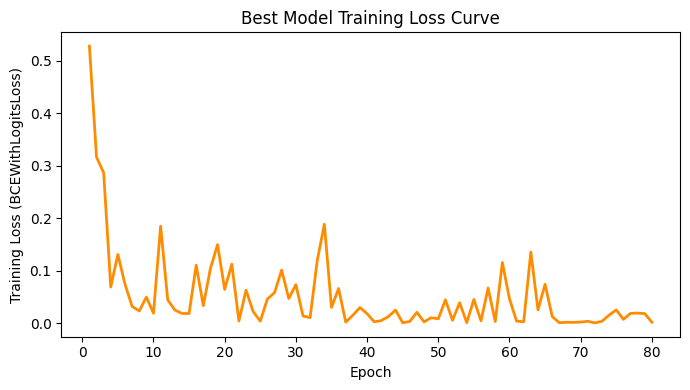

In [18]:
# Training loss curve — shows convergence over epochs
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, color="darkorange", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (BCEWithLogitsLoss)")
plt.title("Best Model Training Loss Curve")
plt.tight_layout()
plt.show()

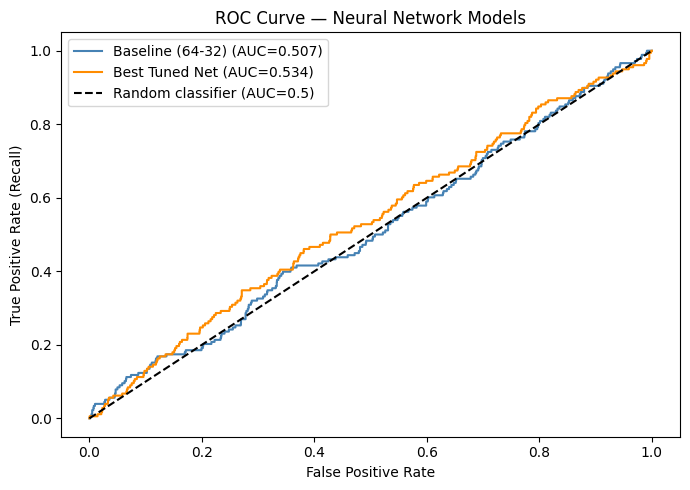

In [19]:
# ROC curve — baseline vs best model (from lecture: FPR vs TPR, AUC)
fig, ax = plt.subplots(figsize=(7, 5))

for metrics, color, label in [
    (baseline_metrics, "steelblue",  "Baseline (64-32)"),
    (best_metrics,     "darkorange", "Best Tuned Net"),
]:
    fpr, tpr, _ = roc_curve(y_test, metrics["_probs"])
    ax.plot(fpr, tpr, color=color, label=f"{label} (AUC={metrics['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random classifier (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Neural Network Models")
ax.legend()
plt.tight_layout()
plt.show()

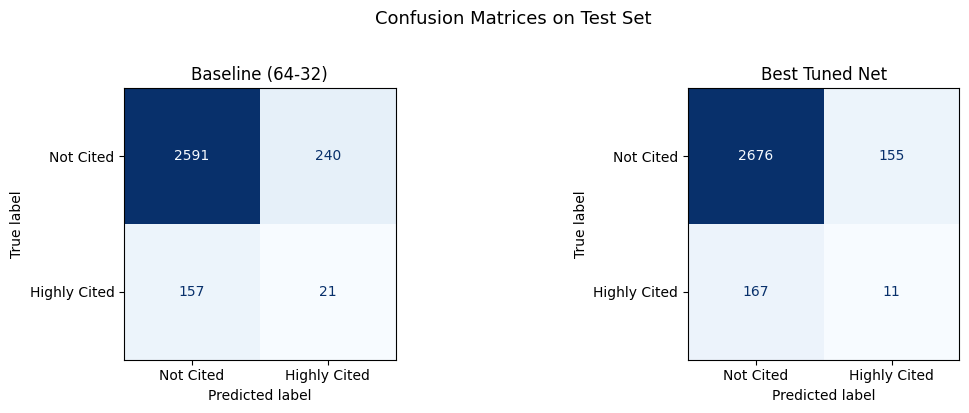

In [20]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metrics, title in [
    (axes[0], baseline_metrics, "Baseline (64-32)"),
    (axes[1], best_metrics,     "Best Tuned Net"),
]:
    cm = confusion_matrix(y_test, metrics["_preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Not Cited", "Highly Cited"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title)

plt.suptitle("Confusion Matrices on Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

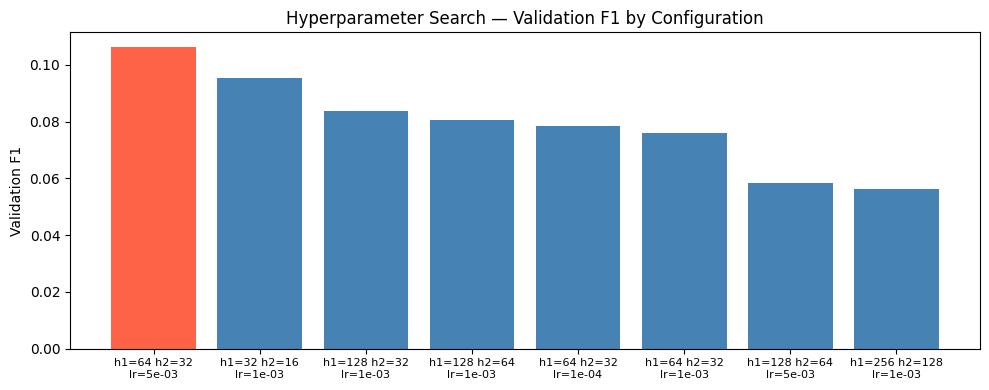

In [21]:
# Hyperparameter search results — validation F1 for each configuration
labels = [
    f"h1={r['n_hidden1']} h2={r['n_hidden2']}\nlr={r['lr']:.0e}"
    for r in hp_df.to_dicts()
]
f1_vals = hp_df["val_f1"].to_list()

plt.figure(figsize=(10, 4))
bars = plt.bar(labels, f1_vals, color=["tomato" if i == 0 else "steelblue" for i in range(len(f1_vals))])
plt.ylabel("Validation F1")
plt.title("Hyperparameter Search — Validation F1 by Configuration")
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

## Feature Importance — Permutation Importance

Neural networks do not have built-in feature importances. We use **permutation importance**: shuffle each input dimension and measure the drop in F1 on the test set. A large drop means the dimension was critical.

We wrap the Lightning model in a thin sklearn-compatible wrapper so we can reuse `permutation_importance`.

In [22]:
class LightningSklearnWrapper(BaseEstimator, ClassifierMixin):
    """Wraps a Lightning model so sklearn's permutation_importance can call predict/score."""

    def __init__(self, lightning_model, threshold=0.5):
        self.lightning_model = lightning_model
        self.threshold = threshold

    def fit(self, X, y):
        return self  # already fitted — wrapper only

    def predict(self, X):
        self.lightning_model.eval()
        with torch.no_grad():
            logits = self.lightning_model(torch.FloatTensor(X)).squeeze(-1)
            return (torch.sigmoid(logits).numpy() >= self.threshold).astype(int)

    def score(self, X, y):  # sklearn uses this for permutation_importance
        return f1_score(y, self.predict(X), zero_division=0)


wrapped = LightningSklearnWrapper(best_model)

perm = permutation_importance(
    wrapped,
    X_test_scaled,  # numpy array (already scaled)
    y_test,
    n_repeats=15,
    random_state=42,
    n_jobs=-1,
)

# Label each SVD component with the original feature that loads most strongly onto it
component_labels = []
for i in range(N_COMPONENTS):
    top_idx = int(np.abs(svd.components_[i]).argmax())
    top_name = original_feature_names[top_idx] if top_idx < len(original_feature_names) else f"feat_{top_idx}"
    component_labels.append(f"SVD-{i} ({top_name[:28]})")

importance_df = pl.DataFrame({
    "component":       component_labels,
    "mean_importance": perm.importances_mean.tolist(),
    "std_importance":  perm.importances_std.tolist(),
}).sort("mean_importance", descending=True)

print("Top 15 most important SVD components:")
importance_df.head(15)

Top 15 most important SVD components:


component,mean_importance,std_importance
str,f64,f64
"""SVD-44 (tldr:performance)""",0.008679,0.006844
"""SVD-38 (tldr:study)""",0.005581,0.009004
"""SVD-0 (publication_year)""",0.005055,0.006762
"""SVD-2 (log_author_count)""",0.004958,0.005454
"""SVD-26 (tldr:time)""",0.002619,0.005109
…,…,…
"""SVD-30 (primary_topic_Computat…",-0.000027,0.010244
"""SVD-39 (primary_topic_Blockcha…",-0.000307,0.010365
"""SVD-32 (tldr:work)""",-0.000482,0.009415


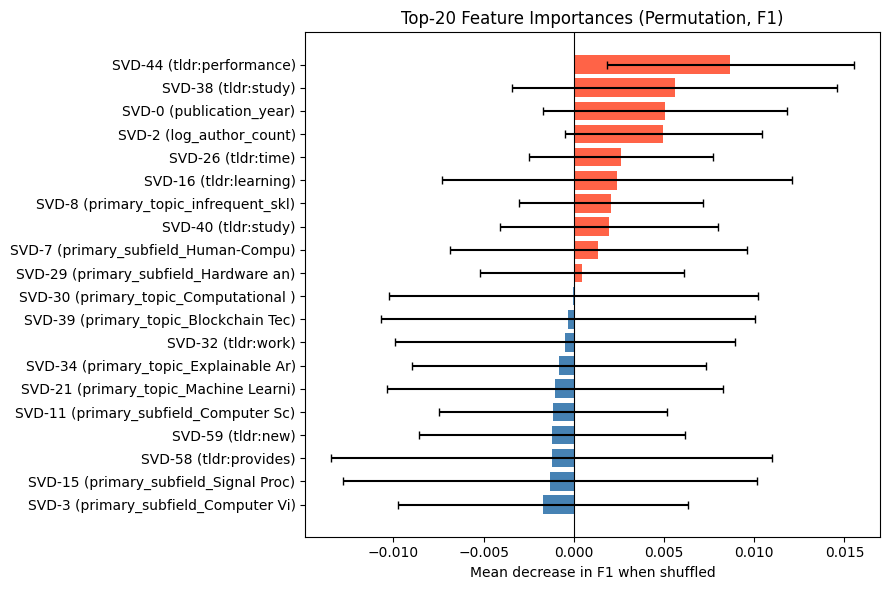

In [23]:
top_n = 20
top = importance_df.head(top_n)
vals = top["mean_importance"].to_list()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top["component"].to_list()[::-1],
    vals[::-1],
    xerr=top["std_importance"].to_list()[::-1],
    color=["tomato" if v > 0 else "steelblue" for v in vals[::-1]],
    capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean decrease in F1 when shuffled")
ax.set_title(f"Top-{top_n} Feature Importances (Permutation, F1)")
plt.tight_layout()
plt.show()

## Model Comparison

We compare three models: a no-oversampling reference, the baseline, and the best tuned network.

In [24]:
# Reference: train without any oversampling to show its effect
X_raw_t = torch.FloatTensor(X_train_scaled)
y_raw_t = torch.FloatTensor(y_train)
raw_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_raw_t, y_raw_t),
    batch_size=BATCH_SIZE, shuffle=True,
)

no_os_model = PaperCitationNet(n_features=N_FEATURES, n_hidden1=64, n_hidden2=32, lr=1e-3)
L.Trainer(
    max_epochs=50, accelerator="auto",
    enable_progress_bar=False, enable_model_summary=False, logger=False,
).fit(no_os_model, train_dataloaders=raw_loader)

no_os_metrics = evaluate_model(no_os_model, X_test_t, y_test, "No oversampling")

comparison_df = pl.DataFrame([
    {k: v for k, v in m.items() if not k.startswith("_")}
    for m in [no_os_metrics, baseline_metrics, best_metrics]
])

print("Model Comparison on Test Set:")
comparison_df

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


`Trainer.fit` stopped: `max_epochs=50` reached.


Model Comparison on Test Set:


model,accuracy,precision,recall,f1,roc_auc
str,f64,f64,f64,f64,f64
"""No oversampling""",0.9172,0.0723,0.0337,0.046,0.5096
"""Baseline (64-32)""",0.8681,0.0805,0.118,0.0957,0.5071
"""Best Tuned Net""",0.893,0.0663,0.0618,0.064,0.5344


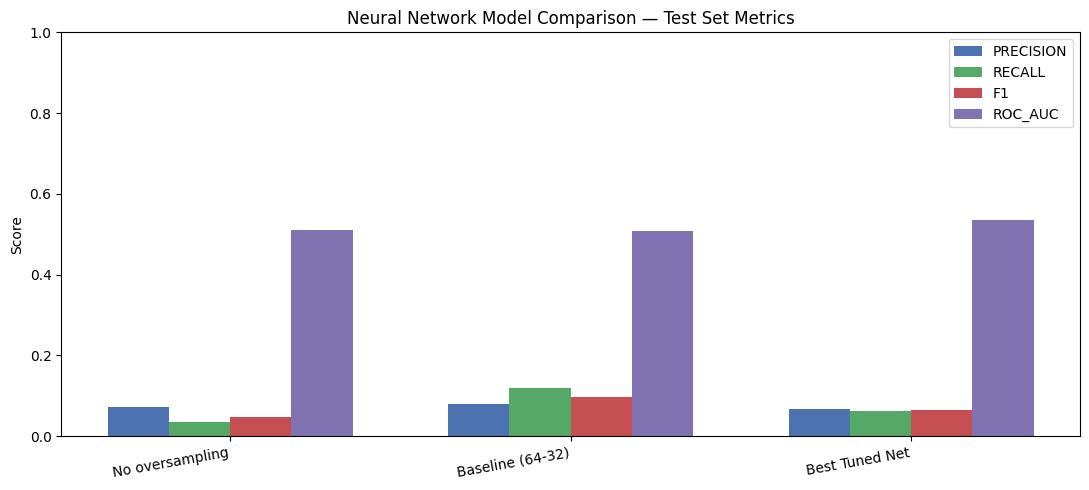

In [25]:
metrics_to_plot = ["precision", "recall", "f1", "roc_auc"]
model_names = comparison_df["model"].to_list()
x = np.arange(len(model_names))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, metric in enumerate(metrics_to_plot):
    values = [v if v is not None else 0.0 for v in comparison_df[metric].to_list()]
    ax.bar(x + i * width, values, width, label=metric.upper(), color=palette[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=10, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Neural Network Model Comparison — Test Set Metrics")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Limitations and Conclusions

### What the Neural Network Adds
- The no-oversampling model predicts almost entirely the majority class (near-zero recall). Oversampling is critical for this heavily imbalanced dataset.
- Hyperparameter tuning via a validation set identifies a better architecture without touching the test set, demonstrating proper model selection.
- The ROC-AUC and classification report provide a richer picture of model quality than accuracy alone — especially important when only ~6% of papers are positive.

### Limitations
1. **Low interpretability.** Unlike the decision tree, the MLP's decisions are distributed across all neurons. Permutation importance gives a post-hoc approximation but cannot explain individual predictions.
2. **Citation count as a lagging indicator.** Most 2026 papers have had little time to accumulate citations, making the target label noisy. The model predicts early citation velocity rather than long-term impact, which limits generalization.
3. **SVD blends semantic meaning.** By projecting into 60 latent dimensions, individual word-level features are blended into components, making feature importance harder to interpret in human terms.
4. **Training sensitivity.** MLPs are sensitive to random initialization and learning rate. More sophisticated tuning (e.g., learning rate scheduling, dropout for regularization) could further improve stability.
5. **Class imbalance handling.** `RandomOverSampler` duplicates existing minority samples, which can overfit to them. SMOTE (synthesizing new points) is a more principled extension, applied at the cost of slightly higher complexity.

### Key Takeaways
- **Oversampling** (applied only on training data, after the split) is the single most impactful change versus the no-oversampling baseline.
- **Validation-set–guided hyperparameter search** selects a better architecture than default choices without touching the test set.
- The neural network complements the decision tree: where the tree offers interpretable splits, the MLP's `predict_proba` scores provide a continuous ranking useful for downstream applications like recommending papers likely to have impact.